In [1]:
import os
import pandas as pd
import numpy as np
import scipy
from scipy.stats import spearmanr

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import rc
import seaborn as sns
import Bio.PDB
from scipy import stats
from Bio.PDB import SASA # SASA module won't load from newest version of Biopython for some reason
# import Geometry # Biopython Geometry module still not on main branch

import time
import sys
import glob
sys.path.append('/data/mhoffert/fiererlab/adenylate_kinase_ogt/protein_utils/')
from collections import Counter

import Geometry

from IPython.display import display, clear_output

### Imports

In [2]:
from scipy.spatial.distance import pdist, squareform

In [3]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

In [7]:
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
from scipy.special import softmax

In [331]:
from scipy.optimize import curve_fit


In [77]:
gtdb_md = pd.read_csv('/data/mhoffert/genomes/GTDB_r214.1/bac120_metadata.tsv.gz', sep='\t', index_col=0)

Columns (61,63,65,74,82,83) have mixed types. Specify dtype option on import or set low_memory=False.


In [8]:
metrics_df = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_full.tsv.gz', sep='\t')
filtered = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_filtered.tsv.gz', sep='\t')

In [9]:
plot_filenames = {col_name: col_name.replace(' ','_').strip('Å²()_').replace('Δ','d').replace('%','percent_') for col_name in metrics_df.columns}
metrics_to_plot = [metric for metric in metrics_df.columns if 'Å' in metric or 'SASA' in metric]
metrics_to_plot = metrics_to_plot + [metric for metric in metrics_df.columns if '%' in metric or 'internal_hbonds' in metric or 'sasa' in metric]
metrics_to_plot = metrics_to_plot + ['cav_vol', 'packstat',  'avg_deg_4_5', 'avg_deg_8', 'avg_sc_nbrs_res_summary', 'avg_cc_contacts_per_res']
print(metrics_to_plot)
include_legend = False

['Contacts at 4.5 Å', 'SASA', 'bb_internal_hbonds', 'bbsc_internal_hbonds', 'internal_hbonds', 'nonpolar_sasa', 'polar_sasa', 'sasa', 'sc_internal_hbonds', '%S', '%L', '%H', 'cav_vol', 'packstat', 'avg_deg_4_5', 'avg_deg_8', 'avg_sc_nbrs_res_summary', 'avg_cc_contacts_per_res']


### Functions

In [134]:
def gaussian_weight_matrix(means: pd.Series, sigma: float) -> np.ndarray:
    distances = squareform(pdist(means.index.values[:, None], 'sqeuclidean'))
    return np.exp(-distances / (2 * sigma ** 2))

def smoothed_means(means: pd.Series, sigma : float) -> pd.Series:
    weight_matrix = gaussian_weight_matrix(means, sigma)
    weighted_sums = weight_matrix @ means.values
    normalizing_factors = weight_matrix.sum(axis=1)
    smoothed_values = weighted_sums / normalizing_factors
    return pd.Series(smoothed_values, index=means.index)

def create_ridgeplot(smoothed_means: pd.Series, std_devs: pd.Series, num_points: int = 100, factor=0.5) -> None:
    
    x = np.linspace(smoothed_means.min() - 3 * std_devs.max(), smoothed_means.max() + 3 * std_devs.max(), num_points)
    cmap = plt.get_cmap('coolwarm')
    norm = Normalize(vmin=smoothed_means.index.min(), vmax=smoothed_means.index.max())

    fig, ax = plt.subplots(figsize=(6, 6))

    for idx, (age, mean, std) in enumerate(zip(smoothed_means.index, smoothed_means, std_devs)):
        y = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)
        color = cmap(norm(age))
        factor = 0.5
        ax.plot(x, y + idx*factor, color='white', lw=1.5)  # Outline in white
        ax.fill_between(x, idx *factor, y + idx*factor, color=color, alpha=1)

    ax.set_yticks(range(int(np.ceil(len(smoothed_means) * factor))))
    # ax.set_yticklabels([f'{age}' for age in smoothed_means.index])
    ax.set_xlabel('Feature X')
    ax.set_title('Ridge Plot of Smoothed Means with Standard Deviations')
    return fig, ax

In [166]:
N_BINS = 21

In [321]:
all_columns = ['Contacts at 4.5 Å', 'SASA', 'bb_internal_hbonds', 'bbsc_internal_hbonds', 'internal_hbonds', 'nonpolar_sasa', 'polar_sasa', 'sasa', 'sc_internal_hbonds', '%S', '%L', '%H', 'cav_vol', 'packstat', 'avg_deg_4_5', 'avg_deg_8', 'avg_sc_nbrs_res_summary', 'avg_cc_contacts_per_res', 'dslf_fa13', 'fa_atr', 'fa_dun', 'fa_elec', 'fa_intra_rep', 'fa_intra_sol_xover4', 'fa_rep', 'fa_sol', 'hbond_bb_sc', 'hbond_sc', 'hbond_sr_bb', 'lk_ball_wtd', 'omega', 'p_aa_pp', 'pro_close', 'rama_prepro', 'ref', 'total_cc_contacts', 'yhh_planarity']

model_data = filtered[all_columns + ['mean_temp'] + ['uid']].drop('dslf_fa13', axis=1)

model_data['temp_group'] = pd.cut(model_data['mean_temp'], np.linspace(0, 80, N_BINS))

train, test = train_test_split(model_data, test_size=0.1)

In [322]:
norm_data = train.groupby('temp_group').apply(lambda x: pd.Series(data=[list(x[c].values) for c in model_data.columns],
                                                        index=model_data.columns)) #.astype(float).drop(['temp', 'temp_group'], 1)

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


### Ridgeplot

In [323]:
_mean = norm_data['SASA'].map(lambda x: np.mean(x) if len(x) > 0 else np.nan)
_std = norm_data['SASA'].map(lambda x: np.std(x) if len(x) > 0 else np.nan)

_mean.index = [i.mid for i in _mean.index]
_std.index = [i.mid for i in _std.index]

In [324]:
plot_means

2.0    NaN
6.0    NaN
10.0   NaN
14.0   NaN
18.0   NaN
22.0   NaN
26.0   NaN
30.0   NaN
34.0   NaN
38.0   NaN
42.0   NaN
46.0   NaN
50.0   NaN
54.0   NaN
58.0   NaN
62.0   NaN
66.0   NaN
70.0   NaN
74.0   NaN
78.0   NaN
dtype: float64

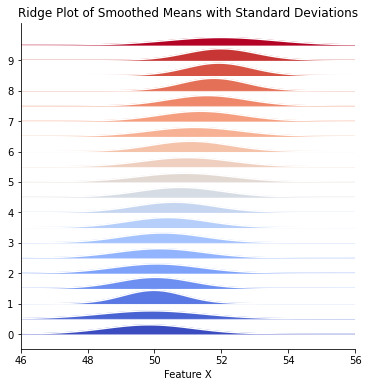

In [326]:
# ridgeplot of smoothing
plot_means = smoothed_means(_mean, 5)
fig, ax = create_ridgeplot(plot_means, _std)
ax.set_xlim(46, 56)
sns.despine()

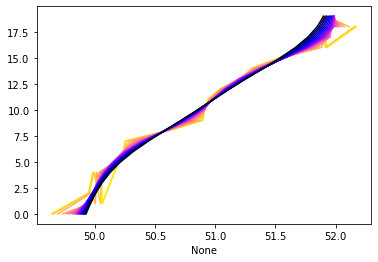

In [327]:
# demonstrate how the smoothing works
n_colors = 21
colors = sns.color_palette('gnuplot2_r', n_colors)
for sigma, c in zip(np.linspace(1e-4, 10, n_colors), colors):
    
    plot_means = smoothed_means(_mean, sigma)
    sns.lineplot(x=plot_means, y=range(len(plot_means)), color=c)

In [333]:
# calculate smoothed means and standard deviations
sigma = 5
all_smeans, all_stds = [], []
for col in norm_data.drop(['uid', 'mean_temp', 'temp_group'], axis=1).columns:
    print(col)
    _mean = norm_data[col].map(lambda x: np.mean(x) if len(x) > 0 else np.nan)
    _std = norm_data[col].map(lambda x: np.std(x) if len(x) > 0 else np.nan)
    _mean.index = [i.mid for i in _mean.index]
    _std.index = [i.mid for i in _std.index]
    smeans = smoothed_means(_mean, sigma)
    all_smeans.append(smeans.rename(col))
    all_stds.append(_std)

Contacts at 4.5 Å
SASA
bb_internal_hbonds
bbsc_internal_hbonds
internal_hbonds
nonpolar_sasa
polar_sasa
sasa
sc_internal_hbonds
%S
%L
%H
cav_vol
packstat
avg_deg_4_5
avg_deg_8
avg_sc_nbrs_res_summary
avg_cc_contacts_per_res
fa_atr
fa_dun
fa_elec
fa_intra_rep
fa_intra_sol_xover4
fa_rep
fa_sol
hbond_bb_sc
hbond_sc
hbond_sr_bb
lk_ball_wtd
omega
p_aa_pp
pro_close
rama_prepro
ref
total_cc_contacts
yhh_planarity


In [334]:
all_smeans = pd.concat(all_smeans, axis=1)
all_stds = pd.concat(all_stds, axis=1)

### probability plots

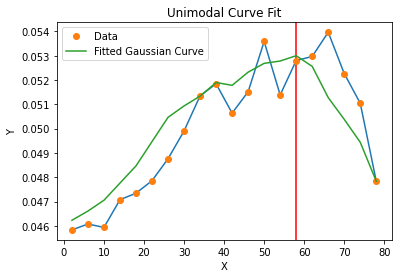

In [335]:
probs = softmax(calculate_probabilities(51.196435, all_smeans['SASA'], all_stds['SASA']))

sns.lineplot(probs)

# x_smooth, y_smooth = fit_unimodal_curve(probs.index.values, probs.values)
x_smooth, y_smooth = probs.index.values, running_average(probs.values, window_size=4)
plt.axvline(x_smooth[y_smooth.argmax()], color='r')
# Plotting the result
plt.plot(probs.index.values, probs.values, 'o', label='Data')
plt.plot(x_smooth, y_smooth, '-', label='Fitted Gaussian Curve')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Unimodal Curve Fit')
plt.show()

In [336]:
def calculate_probabilities(P, means: pd.Series, std_devs: pd.Series) -> pd.Series:
    probabilities = (1 / (np.sqrt(2 * np.pi * std_devs**2))) * np.exp(-((P - means)**2) / (2 * std_devs**2))
    return probabilities

In [337]:
# # Define an exponential decay function
# def exponential_decay(x, a, b, c):
#     return a * np.exp(-b * x) + c

# # Define a Gaussian function for fitting
# def gaussian(x, a, mu, sigma):
#     return a * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

# def logistic(x, L, x0, k):
#     return L / (1 + np.exp(-k * (x - x0)))

# def fit_prob_curve(x_points, y_points):
    
#     # Generate smooth curve data
#     x_smooth = np.linspace(min(x_points), max(x_points), 500)
#     _max = x_points[y_points.argmax()]
    
#     if _max < 15 or _max > 65: # test for different curves
#         # exponential
#         _type = 'Exponential'
       
#         # Initial guesses for a, b, and c
#         initial_guess = [max(y_points), 0.01, min(y_points)]

#         # Fit the curve
#         params, _ = curve_fit(exponential_decay, x_points, y_points, p0=initial_guess, maxfev=5000)
        
#         y_smooth = exponential_decay(x_smooth, *params)
        
#         # old code for logistic
# #         initial_guess = [max(y_points), np.median(x_points), 0.1]

# #         # Fit the logistic curve
# #         params, _ = curve_fit(logistic, x_points, y_points, p0=initial_guess, maxfev=5000)
        
# #         y_smooth = logistic(x_smooth, *params)
        
#     else:
#         _type = 'Gaussian'
#         # gaussian
#         # Initial guesses for the parameters: amplitude, mean, and standard deviation
#         initial_guess = [max(y_points), np.mean(x_points), np.std(x_points)]

#         # Fit the Gaussian curve
#         params, _ = curve_fit(gaussian, x_points, y_points, p0=initial_guess, maxfev=5000)
    
#         y_smooth = gaussian(x_smooth, *params)
    
#     return _type, x_smooth, y_smooth






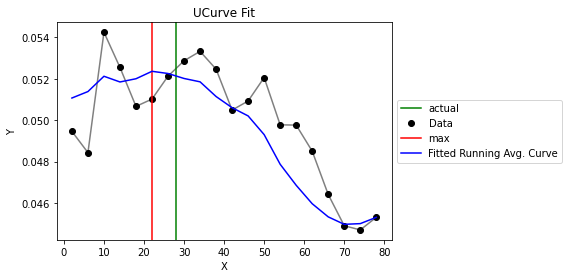

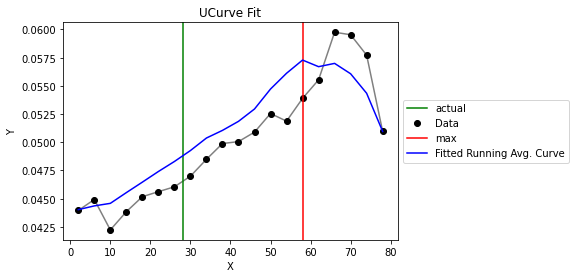

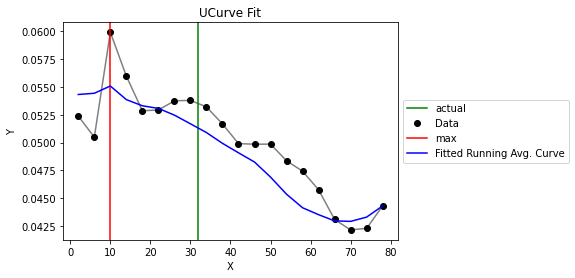

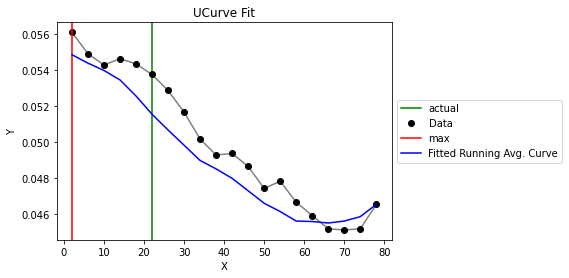

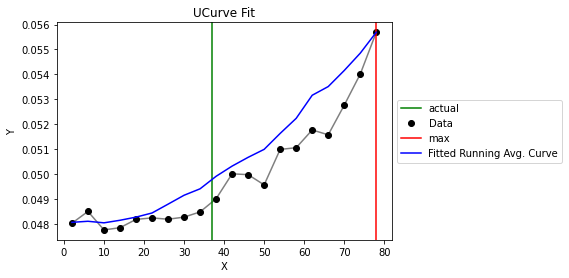

In [339]:
col = 'SASA'
for test_ind in test.head().index:
    # test_ind = 2475
    
    probs = softmax(calculate_probabilities(test.loc[test_ind, col], all_smeans[col], all_stds[col]))
    
    sns.lineplot(probs, color='gray')
    
    plt.axvline(test.loc[test_ind, 'mean_temp'], label='actual', color='green')
    
    
    # # Plotting the result
    plt.plot(probs.index.values, probs.values, 'o', label='Data', color='k')
    
    _type, x_smooth, y_smooth = fit_avg_curve(probs.index.values, probs.values, 5)
    plt.axvline(x_smooth[y_smooth.argmax()], color='r', label='max')
    plt.plot(x_smooth, y_smooth, '-', label=f'Fitted {_type} Curve', color='blue')
    
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('UCurve Fit')
    plt.show()

In [340]:
def running_average(arr, window_size):
    running_avg = []

    for i in range(len(arr)):
        
        # Set the window size as the minimum of i+1 and a fixed size (for example, 5 or 10)
        ws = window_size
        # Calculate the running average up to the current point
        _slice = arr[i:i+ws]
        running_avg.append(sum(_slice) / len(_slice))

    return np.array(running_avg)

def fit_avg_curve(x_points, y_points, ws):
    x_smooth, y_smooth = x_points, running_average(y_points, window_size=ws)
    return 'Running Avg.',  x_smooth, y_smooth

def calc_max_prob(name, data, means, stds, ws=5):
    # print(name)
    probs = calculate_probabilities(data, means, stds)
    _type, x_smooth, y_smooth = fit_avg_curve(probs.index.values, probs.values, ws)
    return x_smooth[y_smooth.argmax()]

In [343]:
all_probs = []
for col in norm_data.drop(['mean_temp', 'temp_group', 'uid'], axis=1).columns:
    all_probs.append(test[[col]].apply(lambda x: calc_max_prob(x.name, x[col], all_smeans[col], all_stds[col]), axis=1).rename(col))

all_probs = pd.concat(all_probs, axis=1)

In [390]:
corrs = all_smeans.apply(lambda col: spearmanr(col.index, col.values)[0], axis=0).sort_values()
best_corrs = pd.concat([corrs.head(), corrs.tail()])

In [391]:
best_corrs

omega                     -0.993985
p_aa_pp                   -0.977444
avg_sc_nbrs_res_summary   -0.950376
cav_vol                   -0.771429
fa_atr                    -0.735338
polar_sasa                 0.926316
avg_deg_8                  0.944361
pro_close                  0.966917
Contacts at 4.5 Å          0.969925
SASA                       1.000000
dtype: float64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


CPU times: user 2.23 s, sys: 54.2 ms, total: 2.29 s
Wall time: 2.18 s


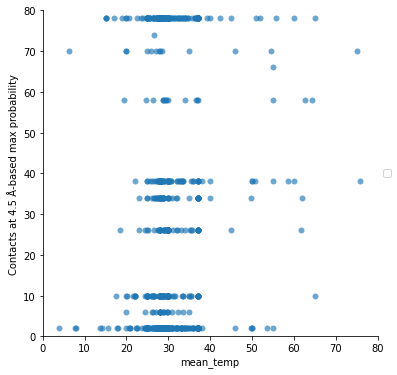

In [392]:
%%time
col = 'Contacts at 4.5 Å'
probs_col = test[[col]].apply(lambda x: calc_max_prob(x.name, x[col], all_smeans[col], all_stds[col]), axis=1)
probs_other = test[[col]].apply(lambda x: calc_max_prob(x.name, x[col], all_smeans[col], all_stds[col]), axis=1)

fig, ax = plt.subplots(figsize=(6,6))
# temp_group_indeces = sorted(list(norm_data.index))
sns.scatterplot(y=probs_col, x=test['mean_temp'], linewidth=0, alpha=0.65) #, hue=filtered.loc[test.index, 'lid_bitscore'], palette='RdBu')
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylabel(f'{col}-based max probability')
ax.set_xlim(0, 80)
ax.set_ylim(0, 80)
sns.despine()

In [393]:
%%time
col = 'p_aa_pp'
probs_col = test[[col]].apply(lambda x: calc_max_prob(x.name, x[col], all_smeans[col], all_stds[col]), axis=1)

print(gtdb_md.loc[test.loc[(probs_col - test['mean_temp']).sort_values().index[:5], 'uid'], 'gtdb_taxonomy'].values)

print(test.loc[(probs_col - test['mean_temp']).sort_values().index[:5], 'mean_temp'])

['d__Bacteria;p__Aquificota;c__Desulfurobacteriia;o__Desulfurobacteriales;f__Desulfurobacteriaceae;g__Balnearium;s__Balnearium lithotrophicum'
 'd__Bacteria;p__Deinococcota;c__Deinococci;o__Deinococcales;f__Thermaceae;g__Thermus;s__Thermus amyloliquefaciens'
 'd__Bacteria;p__Caldisericota;c__Caldisericia;o__Caldisericales;f__Caldisericaceae;g__Caldisericum;s__Caldisericum exile'
 'd__Bacteria;p__Calditrichota;c__Calditrichia;o__Calditrichales;f__Calditrichaceae;g__Caldithrix;s__Caldithrix abyssi'
 'd__Bacteria;p__Bacillota;c__Bacilli;o__Bacillales;f__Aeribacillaceae;g__Aeribacillus;s__Aeribacillus composti']
8246    64.432069
1577    62.750000
576     61.697154
2613    60.000000
5084    58.500000
Name: mean_temp, dtype: float64
CPU times: user 1.09 s, sys: 17.5 ms, total: 1.11 s
Wall time: 1.08 s


In [394]:
worst = (probs_col - test['mean_temp']).sort_values().head()

RS_GCF_003391135.1 d__Bacteria;p__Actinomycetota;c__Actinomycetia;o__Streptomycetales;f__Streptomycetaceae;g__Streptomyces;s__Streptomyces olivoreticuli


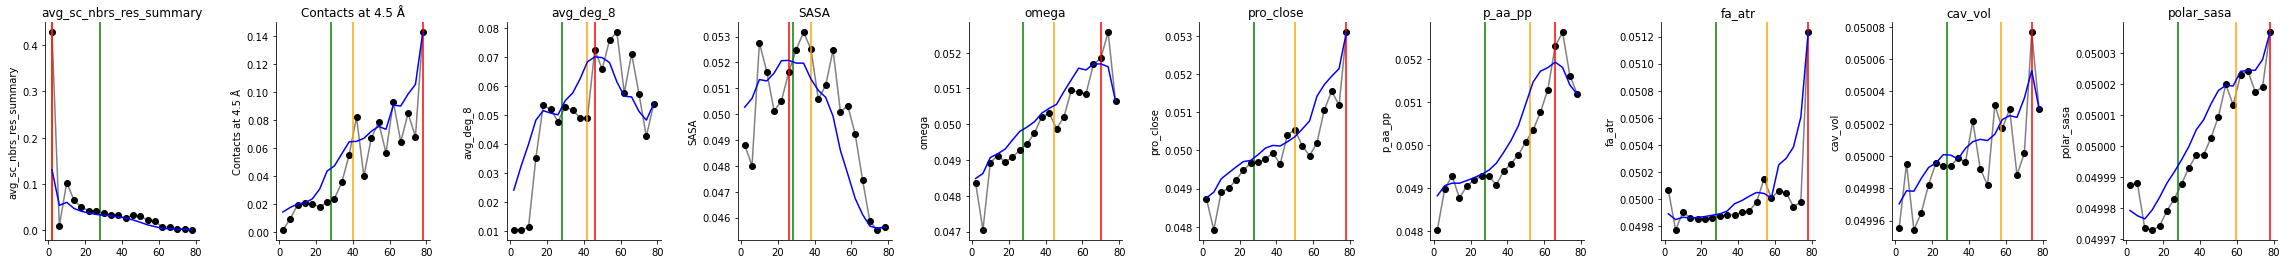

RS_GCF_011304195.1 d__Bacteria;p__Bacillota;c__Bacilli;o__Lactobacillales;f__Vagococcaceae;g__Vagococcus;s__Vagococcus hydrophili


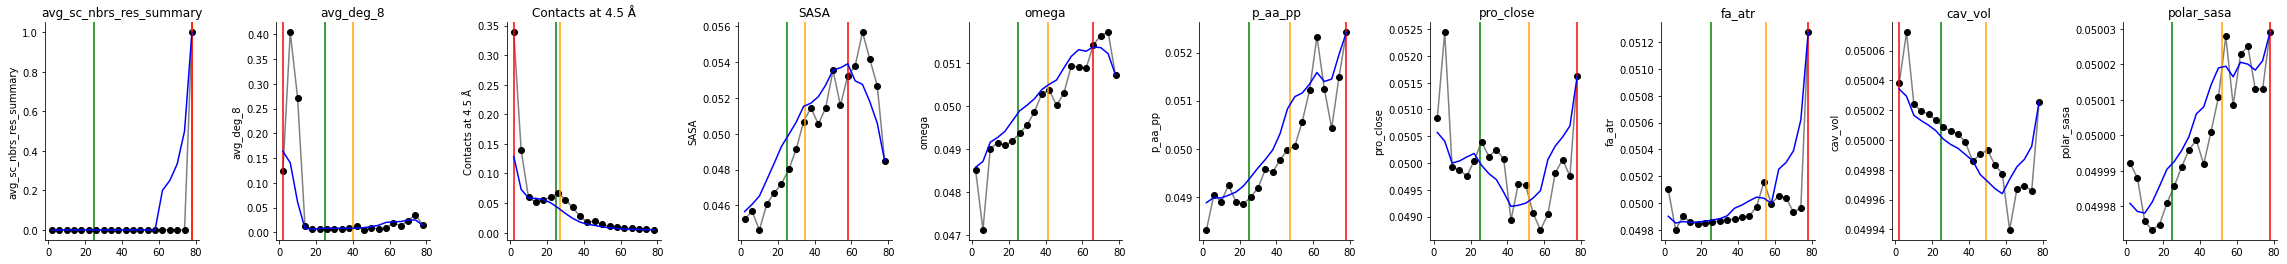

RS_GCF_900115825.1 d__Bacteria;p__Bacillota;c__Bacilli;o__Lactobacillales;f__Carnobacteriaceae;g__Desemzia;s__Desemzia incerta


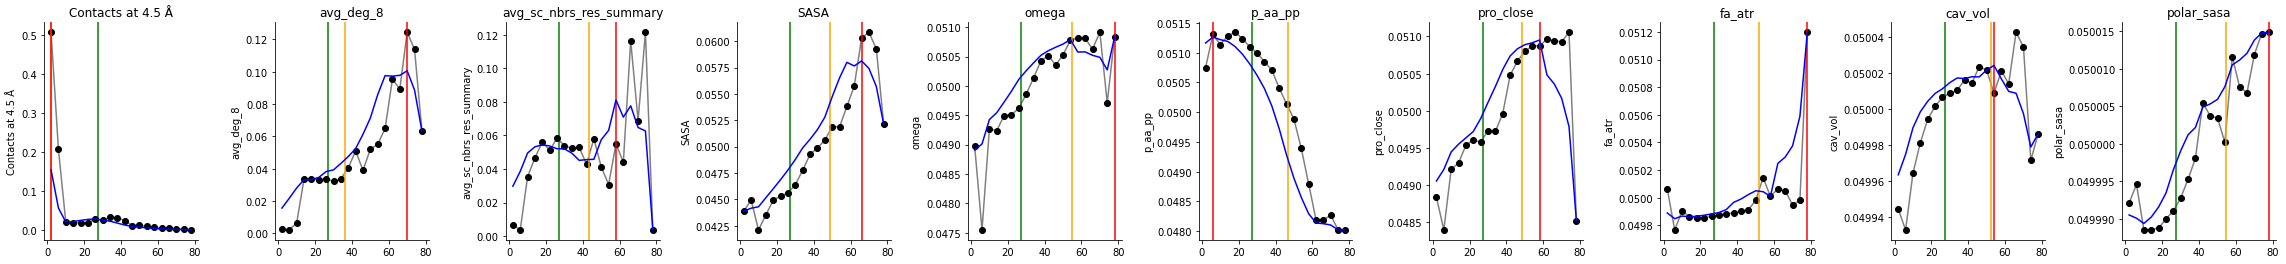

RS_GCF_003967535.1 d__Bacteria;p__Chloroflexota;c__Ktedonobacteria;o__Ktedonobacterales;f__Ktedonobacteraceae;g__Tengunoibacter;s__Tengunoibacter tsumagoiensis


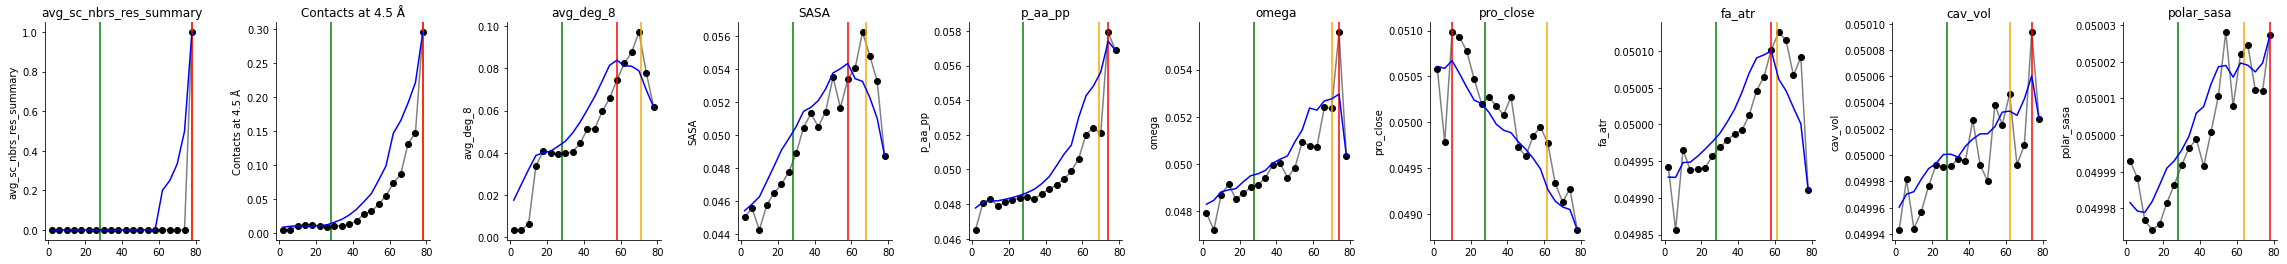

RS_GCF_001434695.1 d__Bacteria;p__Bacillota;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Dellaglioa;s__Dellaglioa algida


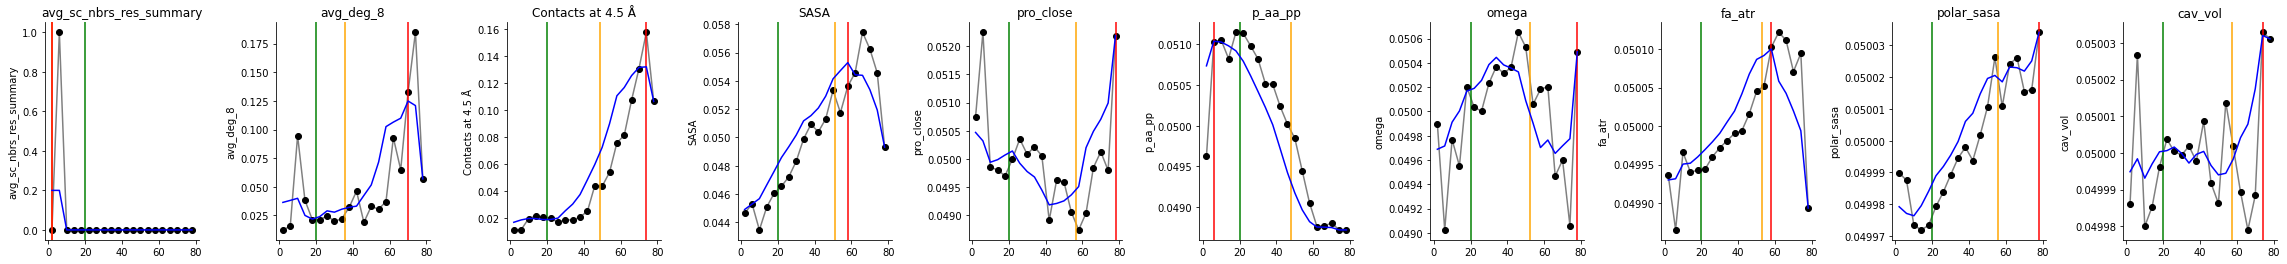

In [398]:
labels = []
# col = 'SASA'

for test_ind, row in test.loc[[3806, 5784, 7938, 4243, 2086]].iterrows():
    # get GTDB data
    print(row['uid'], gtdb_md.loc[row['uid'], 'gtdb_taxonomy'])
    labels.append(gtdb_md.loc[row['uid'], 'gtdb_taxonomy'])
    # test_ind = 2475
    # print(test.loc[test_ind, col])
    fig = plt.figure(figsize=(40, 4))
    probs_list = [softmax(calculate_probabilities(test.loc[test_ind, col], all_smeans[col], all_stds[col])) for col in best_corrs.index]
    probs_dict = dict((i, p) for p, i in zip(probs_list, best_corrs.index))
    probs_series = pd.Series(index=best_corrs.index, 
                           data=[np.max(p) - np.min(p) for p in probs_list])
     
    smoothed_probs = []
    for i, col in enumerate(probs_series.sort_values(ascending=False).index):
        # print(i)
        ax = fig.add_subplot(1, 10, i + 1)
        
        probs = probs_dict[col]
        sns.lineplot(probs, color='gray')

        plt.axvline(test.loc[test_ind, 'mean_temp'], label='actual', color='green')
        
        
        
        # # Plotting the result
        plt.plot(probs.index.values, probs.values, 'o', label='Data', color='k')

        _type, x_smooth, y_smooth = fit_avg_curve(probs.index.values, probs.values, ws=5)
        smoothed_probs.append(x_smooth[y_smooth.argmax()])
        plt.axvline(np.mean(smoothed_probs), color='orange', label='smoothed_prob')
        plt.axvline(x_smooth[y_smooth.argmax()], color='r', label='max')
        plt.plot(x_smooth, y_smooth, '-', label=f'Fitted {_type} Curve', color='blue')
        sns.despine()
        # plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        # plt.xlabel('X')
        # plt.ylabel('Y')
        plt.title(col)
        fig.subplots_adjust(wspace=(0.5))
    plt.show()

In [399]:
all_probs = []
for col in norm_data.drop(['mean_temp', 'temp_group', 'uid'], axis=1).columns:
    
    all_probs.append(softmax(calculate_probabilities(test.loc[test_ind, col], all_smeans[col], all_stds[col])))

all_probs = pd.concat(all_probs, axis=1)



2.0     0.049986
6.0     0.050027
10.0    0.049980
14.0    0.049985
18.0    0.049996
22.0    0.050004
26.0    0.050000
30.0    0.049999
34.0    0.050002
38.0    0.049998
42.0    0.050009
46.0    0.049992
50.0    0.049986
54.0    0.050014
58.0    0.050002
62.0    0.049989
66.0    0.049979
70.0    0.049988
74.0    0.050033
78.0    0.050031
Name: cav_vol, dtype: float64

In [400]:
all_probs

,Contacts at 4.5 Å,SASA,bb_internal_hbonds,bbsc_internal_hbonds,internal_hbonds,nonpolar_sasa,polar_sasa,sasa,sc_internal_hbonds,%S,...,hbond_sc,hbond_sr_bb,lk_ball_wtd,omega,p_aa_pp,pro_close,rama_prepro,ref,total_cc_contacts,yhh_planarity
3402,2.0,22.0,50.0,58.0,22.0,2.0,10.0,78.0,30.0,78.0,...,38.0,22.0,50.0,34.0,2.0,2.0,58.0,10.0,2.0,26.0
791,2.0,58.0,26.0,58.0,26.0,22.0,10.0,14.0,38.0,14.0,...,38.0,22.0,78.0,74.0,6.0,2.0,74.0,74.0,22.0,50.0
8513,2.0,10.0,50.0,42.0,78.0,78.0,78.0,78.0,78.0,2.0,...,10.0,2.0,78.0,10.0,74.0,58.0,2.0,74.0,78.0,2.0
4219,10.0,2.0,78.0,78.0,78.0,2.0,10.0,2.0,78.0,78.0,...,62.0,2.0,38.0,6.0,74.0,2.0,74.0,2.0,78.0,6.0
1449,34.0,78.0,14.0,58.0,22.0,38.0,10.0,10.0,38.0,14.0,...,38.0,78.0,14.0,78.0,6.0,2.0,74.0,54.0,22.0,26.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4693,10.0,10.0,50.0,58.0,50.0,58.0,10.0,78.0,74.0,58.0,...,10.0,22.0,10.0,10.0,46.0,78.0,78.0,10.0,14.0,50.0
4243,78.0,58.0,58.0,78.0,2.0,54.0,78.0,78.0,62.0,58.0,...,78.0,2.0,46.0,74.0,74.0,10.0,34.0,74.0,78.0,50.0
1905,78.0,2.0,78.0,42.0,2.0,42.0,50.0,2.0,78.0,78.0,...,78.0,2.0,2.0,70.0,2.0,2.0,78.0,74.0,2.0,22.0
3888,2.0,50.0,18.0,58.0,22.0,22.0,10.0,14.0,74.0,14.0,...,2.0,30.0,54.0,74.0,10.0,2.0,2.0,2.0,22.0,22.0


In [371]:
corrs = all_smeans.apply(lambda col: spearmanr(col.index, col.values)[0], axis=0).sort_values()
best_corrs = pd.concat([corrs.head(10), corrs.tail(10)])

In [372]:
best_corrs

omega                     -0.993985
p_aa_pp                   -0.977444
avg_sc_nbrs_res_summary   -0.950376
cav_vol                   -0.771429
fa_atr                    -0.735338
ref                       -0.712782
fa_elec                   -0.685714
hbond_sr_bb               -0.574436
%H                        -0.545865
rama_prepro               -0.440602
hbond_bb_sc                0.775940
%S                         0.792481
fa_intra_sol_xover4        0.804511
sasa                       0.812030
fa_dun                     0.881203
polar_sasa                 0.926316
avg_deg_8                  0.944361
pro_close                  0.966917
Contacts at 4.5 Å          0.969925
SASA                       1.000000
dtype: float64

In [406]:
corkrey_matches = pd.read_csv('/data/mhoffert/fiererlab/ogt/results/db/corkey_gtdb_matching.tsv', sep='\t', index_col=0)
corkrey_data = pd.read_csv('/data/mhoffert/fiererlab/ogt/source_data/Corkey_temperatures.csv')
corkrey_full = pd.merge(corkrey_data.groupby('binomial.name').agg({'T.C':'mean'}), corkrey_matches, left_index=True, right_on='original_id')

corkrey_full = corkrey_full.groupby('match_accession').agg({'T.C':'mean'})

,T.C
match_accession,
RS_GCF_000143685.1,37.000000
RS_GCF_000153485.2,9.686770
RS_GCF_000166355.1,65.000000
RS_GCF_000196875.2,27.103333
RS_GCF_000212395.1,55.000000
RS_GCF_000284335.1,62.557397
RS_GCF_000378625.1,6.571429
RS_GCF_002216005.1,52.000000
RS_GCF_002441695.1,14.590352


In [415]:
labels = []
# col = 'SASA'
all_smoothed_probs = []
# subset = test[test.uid.isin(corkrey_full[corkrey_full.index.isin(test['uid'])].index)]
subset = test
for test_ind, row in subset.iterrows():
    display(test_ind)
    clear_output(wait=True)
    probs_list = [softmax(calculate_probabilities(test.loc[test_ind, col], all_smeans[col], all_stds[col])) for col in best_corrs.index]
    probs_dict = dict((i, p) for p, i in zip(probs_list, best_corrs.index))
    probs_series = pd.Series(index=best_corrs.index, 
                           data=[np.max(p) - np.min(p) for p in probs_list])
     
    smoothed_probs = []
    for i, col in enumerate(probs_series.sort_values(ascending=False).index):

        probs = probs_dict[col]


        _type, x_smooth, y_smooth = fit_avg_curve(probs.index.values, probs.values, ws=5)
        smoothed_probs.append(x_smooth[y_smooth.argmax()])
        
    all_smoothed_probs.append(np.mean(smoothed_probs))
    plt.show()

1486

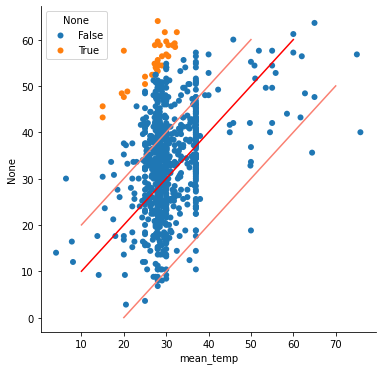

In [439]:
fig, ax = plt.subplots(figsize=(6,6))
predicted_series = pd.Series(data=all_smoothed_probs, index=subset.index)
sns.scatterplot(y=predicted_series, x=test['mean_temp'], hue=(predicted_series - subset['mean_temp']) >= 25, linewidth=0)
plt.plot((10, 60), (10, 60), color='r')
plt.plot((10, 50), (20, 60), color='salmon')
plt.plot((20, 70), (0, 50), color='salmon')
sns.despine()

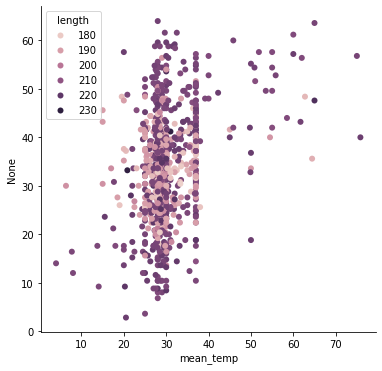

In [417]:
fig, ax = plt.subplots(figsize=(6,6))
predicted_series = pd.Series(data=all_smoothed_probs, index=subset.index)
sns.scatterplot(y=predicted_series, x=test['mean_temp'], hue=filtered['length'], linewidth=0)
sns.despine()

In [405]:
spearmanr(predicted_series, test['mean_temp'])

SpearmanrResult(correlation=0.23275767509237866, pvalue=5.706860715969668e-12)

Index([3806, 5784, 7938, 4243, 2086], dtype='int64')

In [429]:
gtdb_md.loc[test.loc[(predicted_series - test['mean_temp']).sort_values().tail(20).index].uid.values, 'gtdb_taxonomy'].values

array(['d__Bacteria;p__Bacillota;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Liquorilactobacillus;s__Liquorilactobacillus satsumensis',
       'd__Bacteria;p__Actinomycetota;c__Actinomycetia;o__Streptomycetales;f__Streptomycetaceae;g__Kitasatospora;s__Kitasatospora herbaricolor',
       'd__Bacteria;p__Bacillota;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Companilactobacillus;s__Companilactobacillus ginsenosidimutans',
       'd__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Flavobacteriales;f__Weeksellaceae;g__Chryseobacterium;s__Chryseobacterium angstadtii',
       'd__Bacteria;p__Bacillota;c__Bacilli;o__Lactobacillales;f__Carnobacteriaceae;g__Desemzia;s__Desemzia incerta',
       'd__Bacteria;p__Actinomycetota;c__Actinomycetia;o__Streptomycetales;f__Streptomycetaceae;g__Streptomyces;s__Streptomyces kronopolitis',
       'd__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Flavobacteriales;f__Flavobacteriaceae;g__Flavobacterium;s__Flavobacterium circumlabens',
       'd__Bac

In [428]:
(predicted_series - test['mean_temp']).sort_values().tail(20)

2094    27.200000
6631    27.300000
1914    27.300000
1897    27.400000
7938    27.550000
6575    27.600000
4547    27.600000
7830    27.966667
2574    28.200000
1142    28.300000
128     28.900000
7789    29.100000
1830    29.600000
6500    30.300000
8015    30.600000
6735    31.466667
3806    31.600000
684     31.933333
4243    36.000000
2086    37.600000
dtype: float64

In [ ]:
gtdb_md.loc[subset['uid'], 'gtdb_taxonomy'].apply(lambda x: x.split(';')[-1]).unique()


In [ ]:
sns.lineplot(all_smeans['avg_sc_nbrs_res_summary'])
sns.lineplot(all_smeans['avg_sc_nbrs_res_summary'] + all_stds['avg_sc_nbrs_res_summary'])
sns.lineplot(all_smeans['avg_sc_nbrs_res_summary'] - all_stds['avg_sc_nbrs_res_summary'])

In [ ]:
51.587238385257415

In [ ]:
smoothed_means(_mean, sigma)